In [1]:
# 1. Imports
import gurobipy as gp
from gurobipy import GRB
import numpy as np

# 2. Generate sample data
np.random.seed(42)
n_facilities = 100
n_customers = 150
fixed_costs = np.random.randint(100, 200, n_facilities)
demand = np.random.randint(5, 15, n_customers)
shipping_costs = np.random.randint(1, 20, (n_customers, n_facilities))

# 3. Define and solve MIP model
model = gp.Model("FacilityLocation")

x = model.addVars(n_customers, n_facilities, vtype=GRB.BINARY, name="x")
y = model.addVars(n_facilities, vtype=GRB.BINARY, name="y")

# Assign customer to open facilities only
model.addConstrs((x[i,j] <= y[j] for i in range(n_customers) for j in range(n_facilities)), name="AssignIfOpen")

# Each customer is assigned
model.addConstrs((gp.quicksum(x[i,j] for j in range(n_facilities)) == 1 for i in range(n_customers)), name="Demand")

model.setObjective(
    gp.quicksum(fixed_costs[j] * y[j] for j in range(n_facilities)) +
    gp.quicksum(shipping_costs[i,j] * x[i,j] for i in range(n_customers) for j in range(n_facilities)),
    GRB.MINIMIZE
)

model.Params.TimeLimit = 3600
model.setParam('MIPFocus',1)
model.setParam('MIPGap', 0.05)
model.setParam('Heuristics', 0.1)
model.setParam('ImproveStartTime', 30.0)
model.setParam('ImproveStartGap', 0.2)
model.optimize()

Set parameter Username
Set parameter LicenseID to value 2583787
Academic license - for non-commercial use only - expires 2025-11-14
Set parameter TimeLimit to value 3600
Set parameter MIPFocus to value 1
Set parameter Heuristics to value 0.1
Set parameter ImproveStartTime to value 30
Set parameter ImproveStartGap to value 0.2
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) Ultra 5 125U, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 14 logical processors, using up to 14 threads

Non-default parameters:
TimeLimit  3600
Heuristics  0.1
MIPFocus  1
ImproveStartTime  30
ImproveStartGap  0.2

Optimize a model with 15150 rows, 15100 columns and 45000 nonzeros
Model fingerprint: 0x625c4b8a
Variable types: 0 continuous, 15100 integer (15100 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 2e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found h

 If you want to your run to find feasible solutions quickly, then keep model.params.MIPFocus=1; if you are not facing difficulty in finding feasible solutions but want to focus on proving the optimality of these solutions, then keep model.params.MIPFocus=2; or if you want your run to improve the best-objective bound, then keep model.params.MIPFocus=3

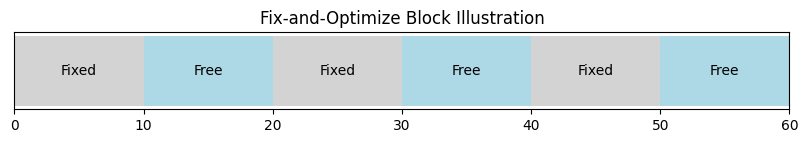

In [2]:
# A toy illustration using matplotlib
import matplotlib.pyplot as plt
import numpy as np

n_blocks = 6
block_labels = ["Fixed", "Free", "Fixed", "Free", "Fixed", "Free"]
colors = ["lightgray", "lightblue"] * 3

fig, ax = plt.subplots(figsize=(10, 1))
for i in range(n_blocks):
    ax.broken_barh([(i*10, 10)], (0, 1), facecolors=colors[i])
    ax.text(i*10 + 5, 0.5, block_labels[i], va='center', ha='center')

ax.set_xlim(0, 60)
ax.set_yticks([])
ax.set_title("Fix-and-Optimize Block Illustration")
plt.show()

In [ ]:
# 1. Imports
import gurobipy as gp
from gurobipy import GRB
import numpy as np

# 2. Generate sample data
np.random.seed(42)
n_facilities = 20
n_customers = 50
fixed_costs = np.random.randint(100, 200, n_facilities)
demand = np.random.randint(5, 15, n_customers)
shipping_costs = np.random.randint(1, 20, (n_customers, n_facilities))

# 3. Define and solve MIP model
model = gp.Model("FacilityLocation")

x = model.addVars(n_customers, n_facilities, vtype=GRB.BINARY, name="x")
y = model.addVars(n_facilities, vtype=GRB.BINARY, name="y")

# Assign customer to open facilities only
model.addConstrs((x[i,j] <= y[j] for i in range(n_customers) for j in range(n_facilities)), name="AssignIfOpen")

# Each customer is assigned
model.addConstrs((gp.quicksum(x[i,j] for j in range(n_facilities)) == 1 for i in range(n_customers)), name="Demand")

model.setObjective(
    gp.quicksum(fixed_costs[j] * y[j] for j in range(n_facilities)) +
    gp.quicksum(shipping_costs[i,j] * x[i,j] for i in range(n_customers) for j in range(n_facilities)),
    GRB.MINIMIZE
)

# model.Params.TimeLimit = 60
model.setParam('Heuristics', 0.1)
model.setParam('ImproveStartTime', 30.0)
model.setParam('ImproveStartGap', 0.1)
# model.setParam('TimeLimit', 60)   

model.optimize()

Set parameter Heuristics to value 0.1
Set parameter ImproveStartTime to value 30
Set parameter ImproveStartGap to value 0.1
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) Ultra 5 125U, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 14 logical processors, using up to 14 threads

Non-default parameters:
Heuristics  0.1
ImproveStartTime  30
ImproveStartGap  0.1

Optimize a model with 1050 rows, 1020 columns and 3000 nonzeros
Model fingerprint: 0x58cda97e
Variable types: 0 continuous, 1020 integer (1020 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 2e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective 3411.0000000
Presolve time: 0.02s
Presolved: 1050 rows, 1020 columns, 3000 nonzeros
Variable types: 0 continuous, 1020 integer (1020 binary)

Root relaxation: objective 4.780000e+02, 656 iterations, 0.00 seco